# Topographic-dominated eddies: PV-gradient control of tilt

## Hypothesis

Planetary-dominated eddies provide the background tilt preference: AEs tend equatorward and CEs poleward, with a shared zonal component. A sufficiently strong topographic PV gradient should override that background preference. As `|∇PV|` increases, tilt should increasingly align with the total PV-gradient direction (`dtheta_PV_grad → 0°`).

CEs are expected to enter this constrained regime more readily because their effective PV gradients are much larger (preliminary estimate: roughly six times the AE magnitude). AEs may retain weak or inconsistent alignment at moderate gradients, then align toward/on to the shelf after crossing a stronger-gradient threshold.

This notebook tests a progressive relationship and possible threshold; it does not assume that a threshold exists. Direction is used only for `TiltDis >= 5 km`, and uncertainty is evaluated at the eddy level.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (ANALYSIS_ROOT, CASE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from case_study_tools import PVAlignmentConfig, add_pv_alignment_diagnostics

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)

## 1. Load data and define the topographic-dominated population

In [2]:
DOMINANCE_FACTOR = 2.0
MAX_DEPTH_m = 3000.0
MIN_TILT_km = 5.0
ALIGNMENT_DEG = 30.0
SHELF_LON = 154.75

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = tilt.add_region_labels(df, grid)
df = tilt.add_pv_gradient_terms(df, grid, core_mean=True)

config = PVAlignmentConfig(
    dominance_factor=DOMINANCE_FACTOR, max_topo_depth_m=MAX_DEPTH_m,
    min_tilt_distance_km=MIN_TILT_km,
)
d = add_pv_alignment_diagnostics(df, config)
topographic = d[d.shallow_ocean_topographic & d.direction_valid].copy()
topographic = topographic[np.isfinite(topographic.PV_grad_mag) & (topographic.PV_grad_mag > 0)]
topographic['log_PV_grad_mag'] = np.log(topographic.PV_grad_mag)
topographic['aligned_30'] = topographic.dtheta_PV_grad <= ALIGNMENT_DEG
topographic['shelf_class'] = np.where(topographic.lon < SHELF_LON, 'On-shelf', 'Off-shelf')

display(topographic.groupby(['Cyc', 'shelf_class']).agg(
    observations=('Eddy', 'size'), eddies=('Eddy', 'nunique'),
    median_PV_grad=('PV_grad_mag', 'median'), median_alignment_deg=('dtheta_PV_grad', 'median'),
    aligned_30_fraction=('aligned_30', 'mean')
).round(3))

observations  eddies  median_PV_grad  median_alignment_deg  \
Cyc shelf_class                                                               
AE  Off-shelf            4936     261             0.0                84.719   
    On-shelf              955      79             0.0                69.519   
CE  Off-shelf            5625     286             0.0                61.867   
    On-shelf             2891     277             0.0                33.768   

                 aligned_30_fraction  
Cyc shelf_class                       
AE  Off-shelf                  0.164  
    On-shelf                   0.204  
CE  Off-shelf                  0.287  
    On-shelf                   0.460

In [11]:
topographic.head()

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,Omega,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region,f,h,dhdx,dhdy,beta,abs_vort,...,PV_grad_plan_x,PV_grad_plan_y,PV_grad_topo_x,PV_grad_topo_y,PV_grad_x,PV_grad_y,PV_grad_plan_mag,PV_grad_plan_theta,PV_grad_topo_mag,PV_grad_topo_theta,PV_grad_mag,PV_grad_theta,dtheta_PV_grad,dtheta_PV_grad_topo,dtheta_PV_grad_plan,Ro,topo_plan_ratio,topo_plan_ratio_smooth,planetary_strong,open_ocean_planetary,topographic_strong,shallow_ocean_topographic,signed_dtheta_PV_grad,expected_PV_theta,expected_direction_error,direction_valid,expected_match,log_PV_grad_mag,aligned_30,shelf_class
118,4,1493,CE,150.518728,-37.464100,92,42,244.562541,208.329230,-0.000050,-0.000021,1.734126,-0.362949,0.657316,37.677021,14.865502,1.837577,22.337952,36,1994-02-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,7.652775,231.141407,S2,-0.000089,2841.435614,-0.091881,0.015586,-1.842593e-11,-0.000139,...,0.0,-6.484724e-15,-1.579465e-12,2.679214e-13,-1.579465e-12,2.614366e-13,6.484724e-15,180.0,1.602027e-12,279.627326,1.600955e-12,279.398516,48.257109,48.485920,51.141407,0.564636,5.509576,5.509576,False,False,True,True,-48.257109,279.398516,48.257109,True,False,-27.160421,False,On-shelf
119,4,1494,CE,150.430296,-37.456043,89,42,236.888864,206.512995,-0.000052,-0.000021,1.618557,-0.563463,0.878391,37.197425,13.298593,1.829614,22.925006,36,1994-02-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,7.981880,243.521114,S2,-0.000089,2083.866016,-0.089614,0.015825,-1.843162e-11,-0.000140,...,0.0,-8.844918e-15,-2.898488e-12,5.118575e-13,-2.898488e-12,5.030126e-13,8.844918e-15,180.0,2.943337e-12,280.014874,2.941811e-12,279.845232,36.324118,36.493760,63.521114,0.584217,5.807456,5.727531,False,False,True,True,-36.324118,279.845232,36.324118,True,True,-26.551996,False,On-shelf
450,9,1465,AE,159.688237,-33.109608,257,193,901.623234,952.329053,0.000032,0.000016,1.051871,0.150987,0.979315,69.182816,-37.989613,1.166617,47.513203,65,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,16.344476,80.566298,D2,-0.000080,2640.642155,0.026634,-0.001990,-1.939791e-11,-0.000047,...,0.0,-7.345906e-15,1.810736e-13,-1.352845e-14,1.810736e-13,-2.087436e-14,7.345906e-15,180.0,1.815783e-13,94.272771,1.822728e-13,96.576091,16.009793,13.706473,99.433702,0.404818,3.207543,3.089655,False,False,True,True,-16.009793,276.576091,163.990207,True,False,-29.333272,True,Off-shelf
451,9,1466,AE,159.561638,-32.983136,254,195,886.519054,961.661738,0.000033,0.000016,0.946863,0.059177,1.094231,65.871209,-35.605415,1.097318,43.471328,65,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,19.693589,63.661540,U2,-0.000079,2973.809188,0.027304,-0.004556,-1.942820e-11,-0.000046,...,0.0,-6.533104e-15,1.415713e-13,-2.362511e-14,1.415713e-13,-3.015821e-14,6.533104e-15,180.0,1.435290e-13,99.474093,1.447479e-13,102.025672,38.364132,35.812553,116.338460,0.422146,3.089655,3.089655,False,False,True,True,-38.364132,282.025672,141.635868,True,False,-29.563783,False,Off-shelf
570,11,1465,AE,159.306405,-29.695098,233,263,763.037374,1301.399904,0.000023,0.000010,1.374811,-0.505572,0.951619,82.024816,-33.575766,1.667901,47.364606,60,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.693924,265.836127,U2,-0.000072,2569.640730,0.003842,-0.001398,-2.009167e-11,-0.000049,...,0.0,-7.818862e-15,2.854271e-14,-1.038342e-14,2.854271e-14,-1.820229e-14,7.818862e-15,180.0,3.037272e-14,109.990651,3.385276e-14,122.526511,143.309616,155.845476,85.836127,0.321248,1.357006,1.195397,False,False,True,True,143.309616,302.526511,36.690384,True,True,-31.016756,False,Off-shelf


## 2. First verify the claimed AE–CE gradient contrast

The six-fold contrast is treated as an empirical claim to estimate, not as an input assumption. Medians are calculated per eddy before comparing polarities.

,Eddy,median_PV_grad,observations
Cyc,,,
AE,1486.5,1.390515e-13,15.0
CE,1499.0,4.606808e-13,12.0


Ratio of CE to AE median eddy-level |∇PV|: 3.31


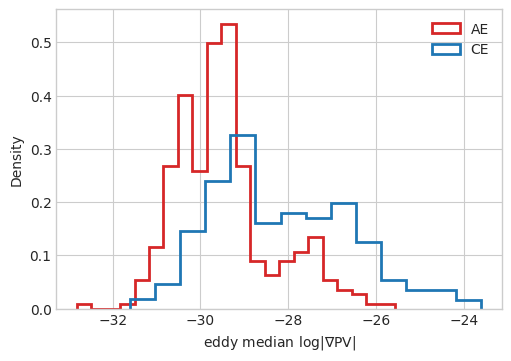

In [3]:
eddy_pv = (topographic.groupby(['Cyc', 'Eddy'], as_index=False)
           .agg(median_PV_grad=('PV_grad_mag', 'median'), observations=('Day', 'size')))
pv_summary = eddy_pv.groupby('Cyc').median(numeric_only=True)
display(pv_summary)
ce_ae_ratio = (pv_summary.loc['CE', 'median_PV_grad'] / pv_summary.loc['AE', 'median_PV_grad'])
print(f'Ratio of CE to AE median eddy-level |∇PV|: {ce_ae_ratio:.2f}')

fig, ax = plt.subplots(figsize=(5, 3.5), constrained_layout=True)
for cyc, color in [('AE', 'tab:red'), ('CE', 'tab:blue')]:
    x = np.log(eddy_pv.loc[eddy_pv.Cyc == cyc, 'median_PV_grad'])
    ax.hist(x, bins='fd', density=True, histtype='step', lw=2, color=color, label=cyc)
ax.set(xlabel=r'eddy median $\log |\nabla \mathrm{PV}|$', ylabel='Density')
ax.legend(frameon=False);

## 3. Map and alignment distributions

A common normalization is used for the AE and CE maps. Separate colour families identify polarity, but equal normalized intensity represents equal `log|∇PV|`.

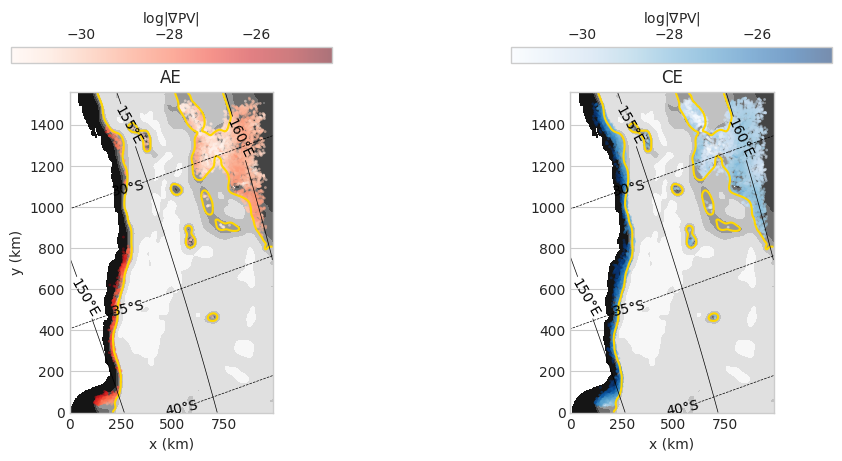

In [4]:
logpv = topographic.log_PV_grad_mag
norm = Normalize(*logpv.quantile([.01, .99]))
fig, axs = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
scats = []
for ax, cyc, cmap in zip(axs, ['AE', 'CE'], ['Reds', 'Blues']):
    part = topographic[topographic.Cyc == cyc]
    ax.contourf(grid.X_grid, grid.Y_grid, np.where(grid.mask_rho, grid.h / 1e3, np.nan), cmap='Greys_r')
    sc = ax.scatter(part.xc, part.yc, c=part.log_PV_grad_mag, cmap=cmap, norm=norm, s=4, alpha=.55, edgecolors='none')
    scats.append(sc)
    ax.contour(grid.X_grid, grid.Y_grid, grid.h, levels=[MAX_DEPTH_m], colors='gold')
    tilt.lat_lon_contours(ax, grid)
    ax.set(title=cyc, xlabel='x (km)', aspect='equal')
    fig.colorbar(sc, ax=ax, location='top', label=r'$\log |\nabla \mathrm{PV}|$', fraction=.05, pad=.02)
axs[0].set_ylabel('y (km)');

1.2022522382287049e-12
1.0855322137009771e-13
1.995353994964308e-12
1.916967797095701e-13


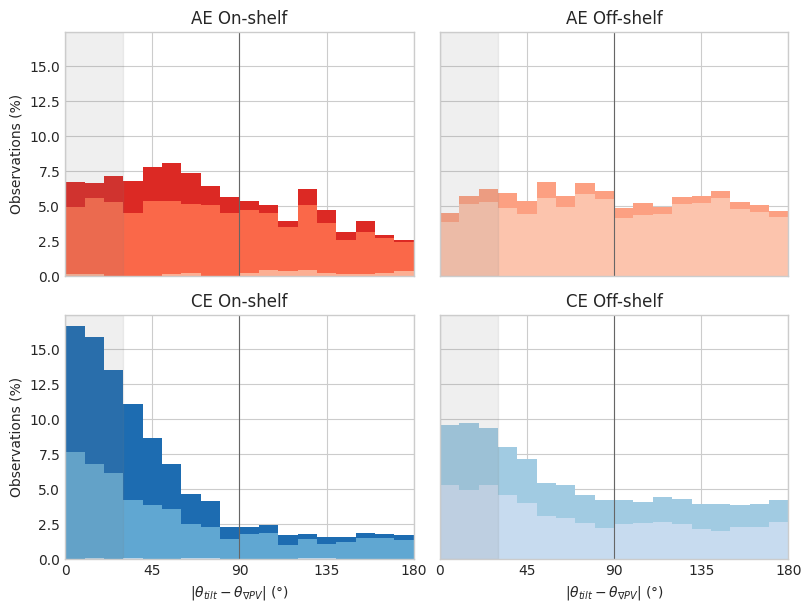

In [15]:
bins = np.arange(0, 181, 10)
fig, axs = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True, constrained_layout=True)
for i, cyc in enumerate(['AE', 'CE']):
    # On-shelf tercile edges are the reference for both columns in this polarity.
    ref = topographic[(topographic.Cyc == cyc) & (topographic.shelf_class == 'On-shelf')]
    # q1, q2 = ref.PV_grad_mag.quantile([1/3, 2/3])

    q2 = 1.995353994964308e-12
    q1 = 1.916967797095701e-13
    
    edges = [-np.inf, q1, q2, np.inf]
    cmap = plt.get_cmap('Reds' if cyc == 'AE' else 'Blues')
    for j, shelf in enumerate(['On-shelf', 'Off-shelf']):
        ax = axs[i, j]
        part = topographic[(topographic.Cyc == cyc) & (topographic.shelf_class == shelf)].copy()
        print(part[part.dtheta_PV_grad>90].PV_grad_mag.mean())
        part['PV_bin'] = pd.cut(part.PV_grad_mag, edges, labels=['Low', 'Medium', 'High'])
        groups, colors = [], []
        for label in ['Low', 'Medium', 'High']:
            group = part[part.PV_bin == label]
            groups.append(group.dtheta_PV_grad)
            colors.append(cmap(norm(group.log_PV_grad_mag.median())))
        weights = [np.ones(len(x)) * 100 / len(part) for x in groups]
        ax.hist(groups, bins=bins, weights=weights, stacked=True, color=colors)
        ax.axvspan(0, ALIGNMENT_DEG, color='0.5', alpha=.12)
        ax.axvline(90, color='0.4', lw=.8)
        ax.set(title=f'{cyc} {shelf}', xlim=(0, 180), xticks=[0, 45, 90, 135, 180])
        if i == 1: ax.set_xlabel(r'$|\theta_{tilt}-\theta_{\nabla PV}|$ (°)')
        if j == 0: ax.set_ylabel('Observations (%)')

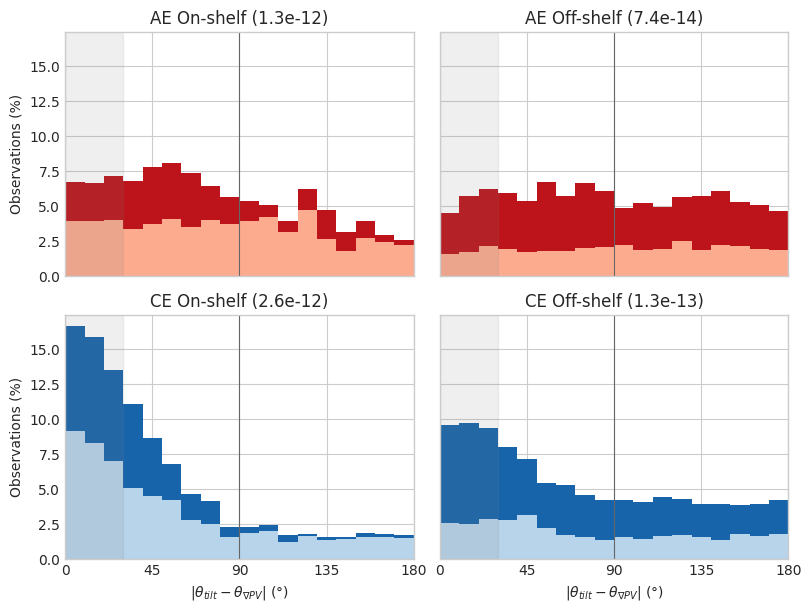

In [16]:
bins = np.arange(0, 181, 10)
fig, axs = plt.subplots(2, 2, figsize=(8,6), sharex=True, sharey=True, constrained_layout=True)

for i, cyc in enumerate(['AE','CE']):
    cmap = plt.get_cmap('Reds' if cyc=='AE' else 'Blues')
    for j, shelf in enumerate(['On-shelf','Off-shelf']):
        ax = axs[i,j]
        part = topographic[(topographic.Cyc==cyc) & (topographic.shelf_class==shelf)].copy()
        aligned = part.dtheta_PV_grad < 90
        ts = part.PV_grad_mag.quantile(np.linspace(.05,.95,200)).values
        t = max(ts, key=lambda x: (part.PV_grad_mag>x)[aligned].mean()-(part.PV_grad_mag>x)[~aligned].mean())
        part['PV_bin'] = part.PV_grad_mag > t
        groups = [part.loc[~part.PV_bin,'dtheta_PV_grad'], part.loc[part.PV_bin,'dtheta_PV_grad']]
        ax.hist(groups, bins=bins, weights=[np.ones(len(x))*100/len(part) for x in groups],
                stacked=True, color=[cmap(.3),cmap(.8)])
        ax.axvspan(0, ALIGNMENT_DEG, color='0.5', alpha=.12); ax.axvline(90,color='0.4',lw=.8)
        ax.set(title=f'{cyc} {shelf} ({t:.1e})', xlim=(0,180), xticks=[0,45,90,135,180])
        if i==1: ax.set_xlabel(r'$|\theta_{tilt}-\theta_{\nabla PV}|$ (°)')
        if j==0: ax.set_ylabel('Observations (%)')

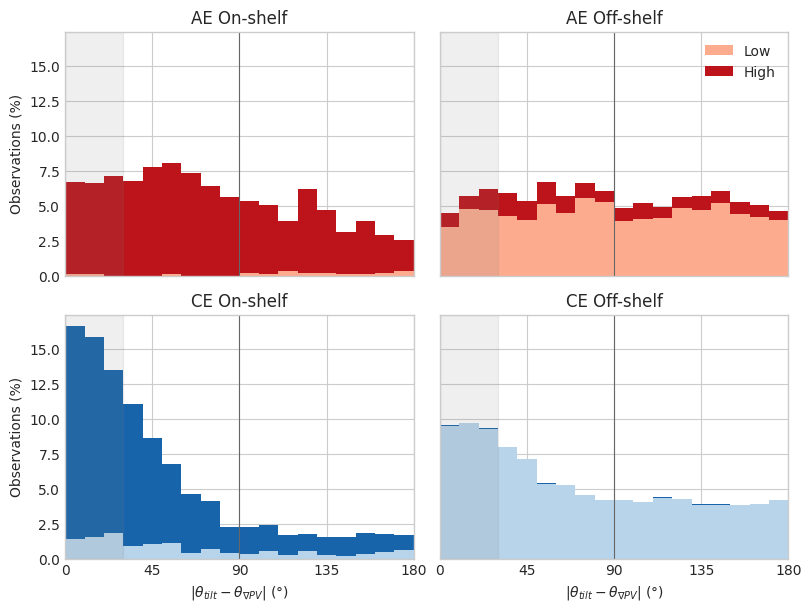

In [17]:
bins = np.arange(0,181,10)
fig, axs = plt.subplots(2,2,figsize=(8,6),sharex=True,sharey=True,constrained_layout=True)

for i,cyc in enumerate(['AE','CE']):
    ref = topographic[topographic.Cyc==cyc]
    a = ref.dtheta_PV_grad<90
    ts = ref.PV_grad_mag.quantile(np.linspace(.05,.95,200))
    t = max(ts,key=lambda x:(ref.PV_grad_mag>x)[a].mean()-(ref.PV_grad_mag>x)[~a].mean())
    cmap = plt.get_cmap('Reds' if cyc=='AE' else 'Blues')

    for j,shelf in enumerate(['On-shelf','Off-shelf']):
        ax = axs[i,j]
        part = ref[ref.shelf_class==shelf].copy()
        part['high'] = part.PV_grad_mag>t
        groups = [part.loc[~part.high,'dtheta_PV_grad'],part.loc[part.high,'dtheta_PV_grad']]
        ax.hist(groups,bins=bins,weights=[np.ones(len(x))*100/len(part) for x in groups],
                stacked=True,color=[cmap(.3),cmap(.8)],label=['Low','High'])
        ax.axvspan(0,ALIGNMENT_DEG,color='0.5',alpha=.12); ax.axvline(90,color='0.4',lw=.8)
        ax.set(title=f'{cyc} {shelf}',xlim=(0,180),xticks=[0,45,90,135,180])
        if i==1: ax.set_xlabel(r'$|\theta_{tilt}-\theta_{\nabla PV}|$ (°)')
        if j==0: ax.set_ylabel('Observations (%)')

axs[0,1].legend(frameon=False)



## 4. Primary test: conditional alignment versus PV-gradient magnitude

Equal-population bins show both the median angular mismatch and the probability of alignment. A forcing threshold would appear as a relatively abrupt decline in angle and rise in alignment probability, especially for AEs. A smooth trend would instead support progressive constraint without a sharp threshold.

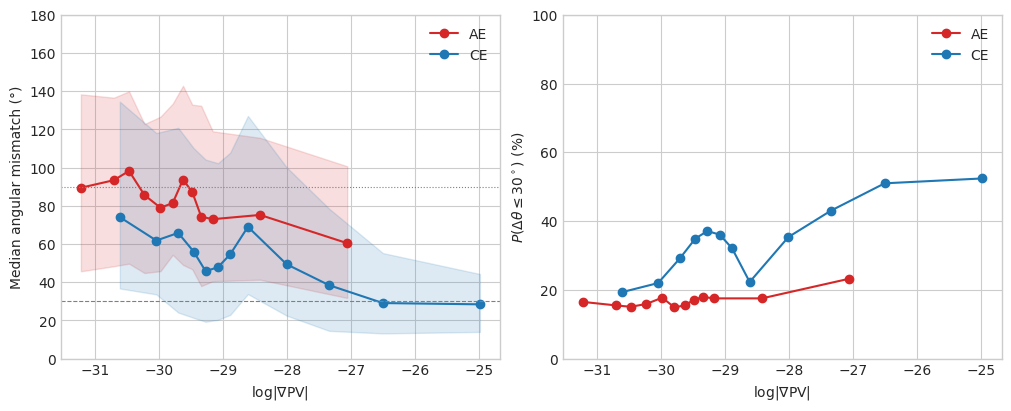

In [6]:
def binned_alignment(part, n_bins=12):
    part = part.copy()
    part['PV_bin'] = pd.qcut(part.log_PV_grad_mag, n_bins, duplicates='drop')
    return (part.groupby('PV_bin', observed=True)
            .agg(logPV=('log_PV_grad_mag', 'median'), angle=('dtheta_PV_grad', 'median'),
                 q25=('dtheta_PV_grad', lambda x: x.quantile(.25)),
                 q75=('dtheta_PV_grad', lambda x: x.quantile(.75)),
                 p_aligned=('aligned_30', 'mean'), n=('Eddy', 'size'), eddies=('Eddy', 'nunique'))
            .reset_index(drop=True))

fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for cyc, color in [('AE', 'tab:red'), ('CE', 'tab:blue')]:
    stats = binned_alignment(topographic[topographic.Cyc == cyc])
    axs[0].plot(stats.logPV, stats.angle, '-o', color=color, label=cyc)
    axs[0].fill_between(stats.logPV, stats.q25, stats.q75, color=color, alpha=.15)
    axs[1].plot(stats.logPV, 100 * stats.p_aligned, '-o', color=color, label=cyc)
axs[0].axhline(90, color='0.5', ls=':', lw=.8)
axs[0].axhline(ALIGNMENT_DEG, color='0.5', ls='--', lw=.8)
axs[0].set(xlabel=r'$\log |\nabla \mathrm{PV}|$', ylabel='Median angular mismatch (°)', ylim=(0, 180))
axs[1].set(xlabel=r'$\log |\nabla \mathrm{PV}|$', ylabel=rf'$P(\Delta\theta \leq {ALIGNMENT_DEG:.0f}^\circ)$ (%)', ylim=(0, 100))
for ax in axs: ax.legend(frameon=False)

## 5. Does tilt magnitude change the result?

The 5 km cutoff removes the least meaningful bearings. This sensitivity plot repeats the relationship for progressively larger tilt displacements; a physical alignment signal should not be created solely by the cutoff.

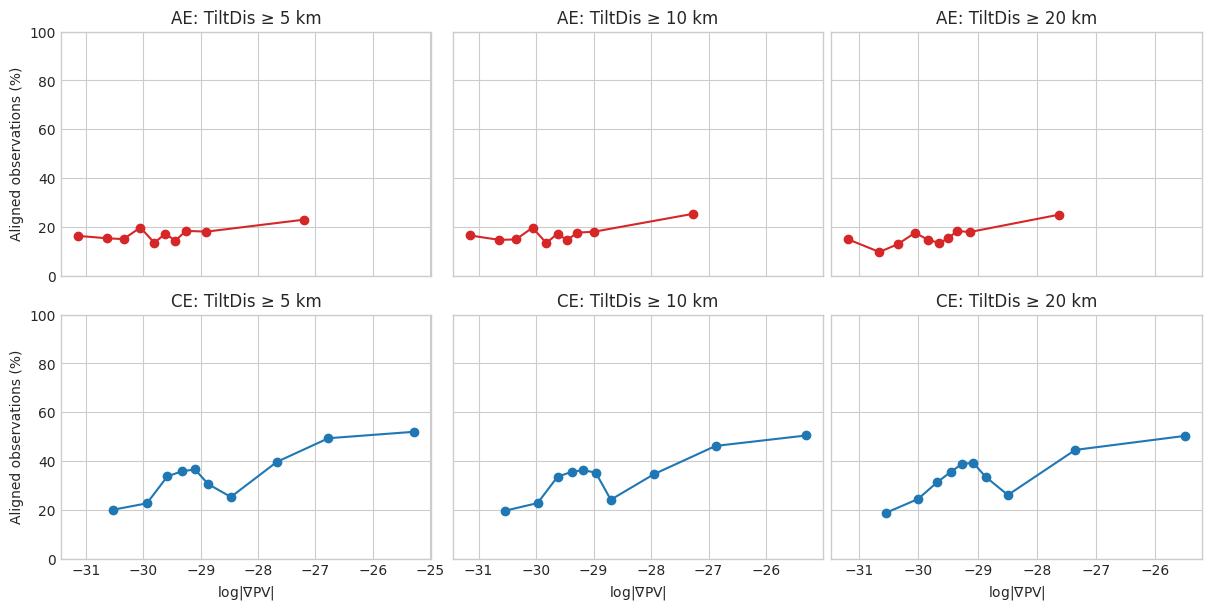

In [7]:
fig, axs = plt.subplots(2, 3, figsize=(12, 6), sharex='col', sharey=True, constrained_layout=True)
for j, min_tilt in enumerate([5, 10, 20]):
    for i, (cyc, color) in enumerate([('AE', 'tab:red'), ('CE', 'tab:blue')]):
        part = topographic[(topographic.Cyc == cyc) & (topographic.TiltDis >= min_tilt)]
        stats = binned_alignment(part, n_bins=10)
        axs[i, j].plot(stats.logPV, 100 * stats.p_aligned, '-o', color=color)
        axs[i, j].set(title=f'{cyc}: TiltDis ≥ {min_tilt} km', ylim=(0, 100))
        if i == 1: axs[i, j].set_xlabel(r'$\log |\nabla \mathrm{PV}|$')
        if j == 0: axs[i, j].set_ylabel('Aligned observations (%)')

## 6. Eddy-level trend estimates

Estimate one slope per eddy where enough gradient variation exists. The distribution of slopes asks whether the relationship recurs across eddies rather than being driven by a few long tracks. Negative angular slopes and positive alignment-probability slopes support the hypothesis.

In [8]:
slope_rows = []
for (cyc, eddy), part in topographic.groupby(['Cyc', 'Eddy']):
    if len(part) < 10 or part.log_PV_grad_mag.nunique() < 4:
        continue
    angle_slope = np.polyfit(part.log_PV_grad_mag, part.dtheta_PV_grad, 1)[0]
    aligned_slope = np.polyfit(part.log_PV_grad_mag, part.aligned_30.astype(float), 1)[0]
    slope_rows.append({'Cyc': cyc, 'Eddy': eddy, 'n': len(part),
                       'angle_slope_deg_per_logPV': angle_slope,
                       'alignment_slope_per_logPV': aligned_slope})
slopes = pd.DataFrame(slope_rows)
display(slopes.groupby('Cyc').agg(
    eddies=('Eddy', 'size'), median_angle_slope=('angle_slope_deg_per_logPV', 'median'),
    fraction_negative_angle=('angle_slope_deg_per_logPV', lambda x: (x < 0).mean()),
    median_alignment_slope=('alignment_slope_per_logPV', 'median'),
    fraction_positive_alignment=('alignment_slope_per_logPV', lambda x: (x > 0).mean())
).round(3))

,eddies,median_angle_slope,fraction_negative_angle,median_alignment_slope,fraction_positive_alignment
Cyc,,,,,
AE,224,2.038,0.473,0.0,0.304
CE,327,-6.858,0.593,0.0,0.440


## 7. Interpretation and next statistical model

A convincing result requires agreement among: (1) binned angle distributions, (2) alignment probability, (3) tilt-distance sensitivity, and (4) within-eddy slopes. A formal follow-up should use a mixed-effects or clustered model with eddy as the grouping unit, allow nonlinear dependence on `log|∇PV|`, and test a polarity-by-gradient interaction. A segmented model should only be used to claim a threshold if it materially improves out-of-sample fit over a smooth monotonic alternative.